## MNIST 학습 데이터 만들기

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, t_train),(x_test, t_test)=mnist.load_data()

print('\n train shape = ', x_train.shape, ', train label shape = ', t_train.shape)
print('test shape = ', x_test.shape, ', test label shape = ', t_test.shape)

print('\n train label = ',t_train)
print(' test label = ',t_test)
      


 train shape =  (60000, 28, 28) , train label shape =  (60000,)
test shape =  (10000, 28, 28) , test label shape =  (10000,)

 train label =  [5 0 4 ... 5 6 8]
 test label =  [7 2 1 ... 4 5 6]


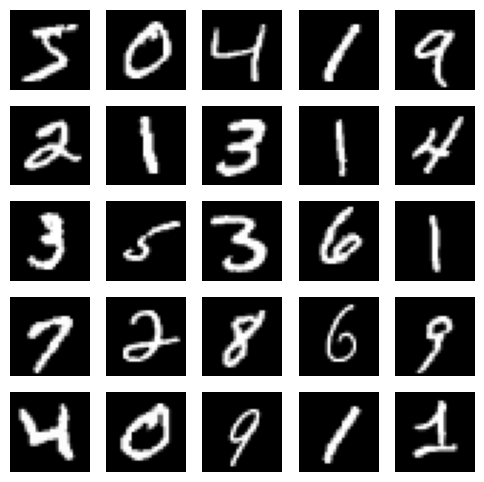

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for index in range(25):
    plt.subplot(5,5,index+1)
    plt.imshow(x_train[index],cmap='gray')
    plt.axis('off')
    
plt.show()

In [3]:
x_train=(x_train-0.0)/(255.0-0.0)
x_test=(x_test-0.0)/(255.0-0.0)

t_train=tf.keras.utils.to_categorical(t_train, num_classes=10)
t_test=tf.keras.utils.to_categorical(t_test, num_classes=10)

In [4]:
model=tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(100,activation='relu'))
model.add(tf.keras.layers.Dense(10,activation='softmax'))

C:\Users\dlwjd\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
hist=model.fit(x_train,t_train,epochs=30,validation_split=0.3)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9106 - loss: 0.3171 - val_accuracy: 0.9479 - val_loss: 0.1818
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9586 - loss: 0.1426 - val_accuracy: 0.9611 - val_loss: 0.1347
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9705 - loss: 0.0998 - val_accuracy: 0.9667 - val_loss: 0.1133
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9781 - loss: 0.0742 - val_accuracy: 0.9682 - val_loss: 0.1101
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9827 - loss: 0.0580 - val_accuracy: 0.9697 - val_loss: 0.1057
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9861 - loss: 0.0468 - val_accuracy: 0.9699 - val_loss: 0.1089
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9887 - loss: 0.0371 - val_accuracy: 0.9727 - val_loss: 0.0981
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9915 -

In [7]:
model.evaluate(x_test,t_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9756 - loss: 0.1359


[0.1358674317598343, 0.975600004196167]

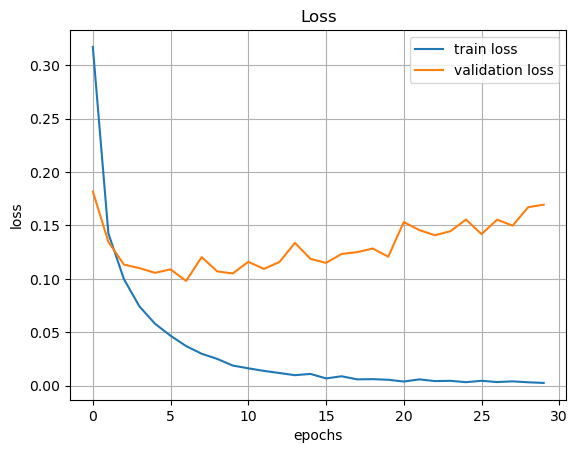

In [8]:
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()

plt.plot(hist.history['loss'], label='train loss')
plt.plot(hist.history['val_loss'], label='validation loss')

plt.legend(loc='best')

plt.show()

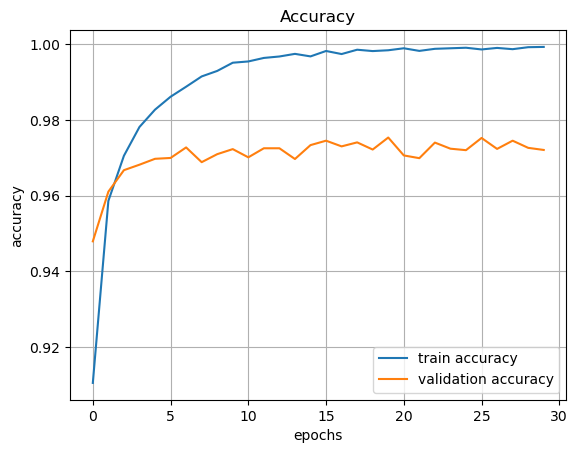

In [9]:
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.grid()

plt.plot(hist.history['accuracy'], label='train accuracy')
plt.plot(hist.history['val_accuracy'], label='validation accuracy')

plt.legend(loc='best')

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


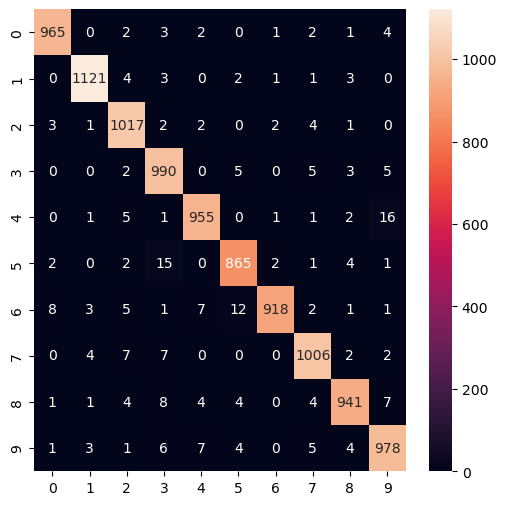

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(6,6))

predicted_value=model.predict(x_test)

cm=confusion_matrix(np.argmax(t_test,axis=-1),np.argmax(predicted_value,axis=1))

sns.heatmap(cm,annot=True,fmt='d')

plt.show()


In [11]:
print(cm)
print('\n')

for i in range(10):
    print(('label=%d\t(%d/%d)\taccuracy=%.3f')%
          (i,np.max(cm[i]),np.sum(cm[i]),
           np.max(cm[i])/np.sum(cm[i])))

[[ 965    0    2    3    2    0    1    2    1    4]
 [   0 1121    4    3    0    2    1    1    3    0]
 [   3    1 1017    2    2    0    2    4    1    0]
 [   0    0    2  990    0    5    0    5    3    5]
 [   0    1    5    1  955    0    1    1    2   16]
 [   2    0    2   15    0  865    2    1    4    1]
 [   8    3    5    1    7   12  918    2    1    1]
 [   0    4    7    7    0    0    0 1006    2    2]
 [   1    1    4    8    4    4    0    4  941    7]
 [   1    3    1    6    7    4    0    5    4  978]]


label=0	(965/980)	accuracy=0.985
label=1	(1121/1135)	accuracy=0.988
label=2	(1017/1032)	accuracy=0.985
label=3	(990/1010)	accuracy=0.980
label=4	(955/982)	accuracy=0.973
label=5	(865/892)	accuracy=0.970
label=6	(918/958)	accuracy=0.958
label=7	(1006/1028)	accuracy=0.979
label=8	(941/974)	accuracy=0.966
label=9	(978/1009)	accuracy=0.969


In [12]:
import tensorflow as tf

# Keras 모델 → TensorFlow Lite 모델로 변환
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 파일로 저장
with open("mnist_model.tflite", "wb") as f:
    f.write(tflite_model)

print("변환 완료!")

INFO:tensorflow:Assets written to: C:\Users\dlwjd\AppData\Local\Temp\tmp1pi_hm9x\assets


INFO:tensorflow:Assets written to: C:\Users\dlwjd\AppData\Local\Temp\tmp1pi_hm9x\assets


Saved artifact at 'C:\Users\dlwjd\AppData\Local\Temp\tmp1pi_hm9x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2111100435920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2111101623888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2111101623504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2111101624464: TensorSpec(shape=(), dtype=tf.resource, name=None)
변환 완료!
